In [257]:
import os
import sys

from dotenv import find_dotenv, load_dotenv
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap
from pathlib import Path

import tempfile
import urllib.parse

In [258]:
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from IPython.display import Image, display

from groq import Groq
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages 
from langgraph.prebuilt import ToolNode, tools_condition 
from langgraph.checkpoint.memory import MemorySaver 
from langchain_core.messages import SystemMessage
from langchain_core.messages import trim_messages
import gradio as gr 

In [259]:

sys.path.append(os.path.abspath("../"))
ruta_datos_llm = Path('../agente_llm/data_llm')
# Detectar dinámicamente la carpeta donde está este archivo: herramientas.py
if '__file__' in locals():
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    BASE_DIR = os.getcwd()


from herramientas import PROMPT_SISTEMA
from herramientas import lista_herramientas_pisa

from src.utils_pisa import *

%load_ext autoreload
%autoreload 2

establecer_semilla(42)
pd.set_option(
    "display.float_format",
    lambda valor: f"{valor:.2f}"
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Semillas del proyecto establecidas con éxito (seed=42).


In [260]:
DIR_IMAGENES = os.path.join(tempfile.gettempdir(), "pisa_plots")
os.makedirs(DIR_IMAGENES, exist_ok=True)


In [261]:
#Carga de la API KEY
env_path = find_dotenv(usecwd=True)
if not env_path:
    raise FileNotFoundError("No encuentro .env.")

load_dotenv(env_path)
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("Añade GROQ_API_KEY a tu archivo .env.")

In [262]:
cliente_groq = Groq(api_key=os.environ.get("GROQ_API_KEY"))
modelos_activos = [m.id for m in cliente_groq.models.list().data if "whisper" not in m.id]
print("Tus modelos disponibles en Groq:")
for m in sorted(modelos_activos):
    print(f" - {m}")

Tus modelos disponibles en Groq:
 - allam-2-7b
 - canopylabs/orpheus-arabic-saudi
 - canopylabs/orpheus-v1-english
 - meta-llama/llama-prompt-guard-2-22m
 - meta-llama/llama-prompt-guard-2-86m
 - openai/gpt-oss-120b
 - openai/gpt-oss-20b
 - openai/gpt-oss-safeguard-20b
 - qwen/qwen3.8-27b


In [263]:
#Creamos la conexión al modelo llm
llm = ChatGroq(temperature=0.0, model_name='openai/gpt-oss-120b') 

#Le pasamos la lista de herramientas
llm_con_herramientas = llm.bind_tools(lista_herramientas_pisa)

In [264]:
#Definimos estado (memoria compartida) con memoria incremental 

class State(TypedDict): #Es un dicionario con claves:valores
    messages: Annotated[list, add_messages]

#Definimos el recortador de historial
recortador = trim_messages(
    max_tokens=20,             # Contamos numeros de mensajes. (token_counter=len), calcula la longitud de la lista: len(mensajes) -> 6 mensajes.
    strategy="last",          # Estrategia: conservar lo último, descartar lo antiguo
    token_counter=len,        # Pásale aquí tu variable del modelo (ej. modelo_groq o llm)
    include_system=True,      # ¡CRUCIAL! Nunca borrará tus instrucciones de sistema
    start_on="human"          # El historial recortado siempre empezará con una pregunta del usuario
)

#Definimos el asistente (modulo de chat principal)
def asistente(state: State): 

   # Unimos el GuardRails (System Prompt) con  el historial
    mensajes_completos = [SystemMessage(content=PROMPT_SISTEMA)] + state["messages"]
    
    # recortamos: Protege el SystemMessage y recorta los mensajes viejos
    mensajes_recortados = recortador.invoke(mensajes_completos)
    
    # Invocamos al LLM con el historial mas ligero
    respuesta = llm_con_herramientas.invoke(mensajes_recortados) 
    
    return {"messages": [respuesta]}

# Use MessagesState to define the state of the stopping function (SE SUSTITUYE POR: tool_conditions)
def debe_continuar(state: State):

    last_message = state ['messages'][-1] #Cogemos el ultimo mensaje 

    #Comprobamos si el ultimo mensaje tiene llamada a herramientas
    if last_message.tool_calls:
        return 'tools'

    # Si no, termina la conversación 
    return END




# *WorkFlow Design* para el agente

In [265]:
#Inicializamos el flujo del grafo
workflow = StateGraph(State)

#Añadimos los nodos
workflow.add_node("asistente", asistente) # Nodo de asistente 

tool_node=ToolNode(lista_herramientas_pisa)
workflow.add_node("tools", tool_node) # Nodo de herramientas Pisa

#Añadimos las conexiones (edges)
workflow.add_edge(START, "asistente") # INICIO

workflow.add_conditional_edges(
    "asistente",
     tools_condition #Si tools_condition devuelve tools, vamos a herramientas. Si no END
) 

workflow.add_edge("tools", "asistente") #Bucle de herramientas al asistene


#Compilación con memoria MemmorySaver
memoria = MemorySaver() 
agente_pisa = workflow.compile(checkpointer=memoria)



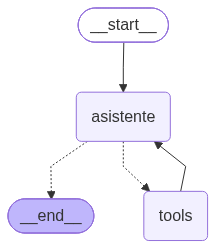

In [266]:
try:

    display(Image(agente_pisa.get_graph().draw_mermaid_png()))

# Return an exception if necessary
except Exception:

    print("Additional dependencies required.")


# Conexión con Gradio

In [267]:

config_hilo = {"configurable": {"thread_id": "sesion_activa1"}}

def responder_chat(mensaje, historial):
    
    print(f"\n--- [DEBUG] Entrada de usuario: {mensaje} ---")
    
    for evento in agente_pisa.stream({"messages": [("user", mensaje)]}, config=config_hilo, stream_mode="updates"):

        for nodo, valor in evento.items():

            print(f"-> Nodo ejecutado: {nodo}")
            ultimo_msg = valor["messages"][-1]
            if hasattr(ultimo_msg, "tool_calls") and ultimo_msg.tool_calls:
                print(f"   [Tool Call detectada]: {ultimo_msg.tool_calls}")
    
    estado = agente_pisa.get_state(config_hilo)
    return estado.values["messages"][-1].content



In [ ]:
# Lanzamos gradio
gr.ChatInterface(
    fn=responder_chat,
    title="Asistente PISA & Machine Learning"
).launch(
    inbrowser=False, 
    inline=True, 
    allowed_paths=[DIR_IMAGENES] 
)

* Running on local URL:  http://127.0.0.1:7891
* To create a public link, set `share=True` in `launch()`.



--- [DEBUG] Entrada de usuario: explicame los factores más influyentes a la hora de obtener un buen resultado de matemáticas ---
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'obtener_importancia_variables', 'args': {}, 'id': 'fc_68502133-76a4-4187-94b5-e5ab1623373b', 'type': 'tool_call'}]
-> Nodo ejecutado: tools
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'generar_grafico_datos_pisa', 'args': {'codigo_plot': "import pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Datos de importancia de variables (top 10)\nvariables = ['Gasto_Alumno_PPP', 'ESCS_media_pais_anual', 'PIB_per_capita_PPP', 'ECS_categoria_Medio', 'Indice_Gini', 'year', 'Perfil_Pais_Emergente_Alta Desigualdad', 'Perfil_Pais_Modelo Igualitario_Inversión Mod.', 'Gasto_Educacion_PIB', 'Perfil_Pais_Alto Esfuerzo Educ_Bajo ESCS']\nimportancias = [0.1139, 0.1052, 0.0934, 0.0909, 0.0826, 0.0781, 0.0759, 0.0723, 0.0716, 0.0667]\n\ndf_imp = pd.DataFrame({'Variable': 

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'generar_grafico_datos_pisa', 'args': {'codigo_plot': "import pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Datos de importancia de variables (top 10)\nvariables = ['Gasto_Alumno_PPP', 'ESCS_media_pais_anual', 'PIB_per_capita_PPP', 'ECS_categoria_Medio', 'Indice_Gini', 'year', 'Perfil_Pais_Emergente_Alta Desigualdad', 'Perfil_Pais_Modelo Igualitario_Inversión Mod.', 'Gasto_Educacion_PIB', 'Perfil_Pais_Alto Esfuerzo Educ_Bajo ESCS']\nimportancias = [0.1139, 0.1052, 0.0934, 0.0909, 0.0826, 0.0781, 0.0759, 0.0723, 0.0716, 0.0667]\n\ndf_imp = pd.DataFrame({'Variable': variables, 'Importancia': importancias})\n# Ordenar para barra horizontal ascendente\ndf_imp = df_imp.sort_values('Importancia', ascending=True)\n\nplt.figure(figsize=(10,6))\nsns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')\nplt.title('Importancia de variables en el modelo XGBoost (Matemáticas)')\nplt.xlabel

<string>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



-> Nodo ejecutado: tools
-> Nodo ejecutado: asistente

--- [DEBUG] Entrada de usuario: entonces las horas que dedica el alumno a estudiar, no son tan relevantes ? ---
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'obtener_importancia_variables', 'args': {}, 'id': 'fc_d0c44928-c471-4830-b14c-0de951d29bc3', 'type': 'tool_call'}]
-> Nodo ejecutado: tools
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'calcular_correlacion_pisa', 'args': {'columna_x': 'tiempo_deberes_totales_diarios_2022', 'columna_y': 'media_math_pais_2022'}, 'id': 'fc_cc5e2c9d-6415-447d-b075-a127c1dcb26d', 'type': 'tool_call'}]
-> Nodo ejecutado: tools
-> Nodo ejecutado: asistente
   [Tool Call detectada]: [{'name': 'generar_grafico_datos_pisa', 'args': {'codigo_plot': "import matplotlib.pyplot as plt\nimport seaborn as sns\nimport pandas as pd\n\n# Suponemos que df_pisa_cnt contiene las columnas necesarias\nx = 'tiempo_deberes_totales_diarios_2022'\ny = 'media_math_pais_2022'\n\n# Fi